# val_05 — The analyses behind the lickometer QC

`val_04_lickometer_qc.ipynb` scores each session by the fraction of contact-like tongue
excursions the lickometer did not record. This notebook holds the work that led to each part of
that definition: why the scoring is restricted to times the lickometer was active, why
"contact-like" is calibrated per session from confirmed contacts, why excursions are timed at
closest approach and scored by whether any lickometer event falls within 100 ms of it,
how the candidates split by lickometer context, and how much the ranking moves when each choice
is changed.

It reads the same event tables as `val_04` and uses the same functions from `lickometer_qc.py`.
Everything except §7 and §8 runs on the exported tables, so it runs locally.

1. Setup
2. Where the raw disagreement comes from
3. Depth and dwell of confirmed and unconfirmed excursions
4. Matching the two streams
5. Lickometer context and the skipped-beat test
6. Sensitivity of the ranking to the choices
7. Confidence threshold (Code Ocean)
8. Trace export (Code Ocean)

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import lickometer_qc as lq
from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [2]:
if Path("/root/capsule").exists():
    ENV     = "codeocean"
    SCRATCH = Path("/root/capsule/scratch")
    EVENTS_DIR = SCRATCH / "figures" / "val_04_lickometer_qc"
else:
    ENV     = "local"
    SCRATCH = Path("/Users/mib/Documents/Code/kinematics_analysis/data")
    EVENTS_DIR = SCRATCH / "for_local"

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "val_05_lickometer_qc_methods"
SAVE_FIG = False
SESSION_DIR = SCRATCH / "session_analysis_mlk"

# The val_04 defaults. Each section below varies one of them.
D0, CONF, T_REFRACTORY, MATCH_WINDOW, ACTIVE_WINDOW = 10, 0.8, 0.1, 0.1, 60.0
DEPTH_Q, DWELL_Q, DWELL_MAX_FACTOR = 0.50, 0.25, 2.0
MIN_CONTACT, MAX_OFFSET_MS, FLAG_MISS = 200, 50.0, 0.05

EXAMPLE = "behavior_791691_2025-06-24_13-21-26"   # the session val_04 walks through

C_CAND, C_CONF, C_GREY = PALETTE["pos"], PALETTE["neg"], PALETTE["not_sig"]
print("ENV={}".format(ENV))

ENV=local


In [3]:
POSE_COLS = ["t_onset", "t_min", "d_min", "n_frames", "span_s", "session"]
pose = pd.read_parquet(EVENTS_DIR / "val_04_pose_events.parquet")[POSE_COLS]
licko = pd.read_parquet(EVENTS_DIR / "val_04_lickometer_events.parquet")[["session", "t"]]
sessions_path = EVENTS_DIR / "val_04_sessions.parquet"
sessions = pd.read_parquet(sessions_path) if sessions_path.exists() else None

# Distance traces around unconfirmed excursions of the example session, when exported (§8).
traces = None
for name in ["val_05_unconfirmed_traces.parquet", "val_04_fn_traces.parquet"]:
    if (EVENTS_DIR / name).exists():
        traces = pd.read_parquet(EVENTS_DIR / name)
        print("traces: {} ({:,} rows, {} windows)".format(
            name, len(traces), traces["fn_index"].nunique()))
        break


def run_pipeline(pose, licko, match_window=MATCH_WINDOW, active_window=ACTIVE_WINDOW,
                 depth_q=DEPTH_Q, dwell_q=DWELL_Q, dwell_max_factor=DWELL_MAX_FACTOR,
                 t_refractory=T_REFRACTORY, time_col="t_min"):
    '''The val_04 pipeline with every parameter exposed. Returns (events, ref, summary).'''
    p = pose.copy()
    if time_col != "t_min":
        # annotate_pose_events measures from t_min; swapping the columns times from the onset.
        p["t_min"], p["t_onset"] = p["t_onset"].to_numpy(), p["t_min"].to_numpy()
    annot = lq.annotate_pose_events(p, licko, t_refractory=t_refractory,
                                    match_window=match_window, active_window=active_window)
    ref = lq.contact_reference(annot, depth_quantile=depth_q, dwell_quantile=dwell_q,
                               dwell_max_factor=dwell_max_factor)
    ev = lq.classify_events(annot, ref)
    lk_kept = {s: (lambda t: t[lq.refractory_mask(t, t_refractory)])(np.sort(g["t"].to_numpy()))
               for s, g in licko.groupby("session")}
    rhythm = {s: lq.lickometer_rhythm(t) for s, t in lk_kept.items()}
    ev["context"] = lq.candidate_context(ev, rhythm)
    summ = lq.summarize_sessions(ev, licko, ref, t_refractory=t_refractory,
                                 match_window=match_window, sessions=sessions)
    summ["gate_pass"] = (summ["n_contact"] >= MIN_CONTACT) & (summ["offset_median_ms"].abs() <= MAX_OFFSET_MS)
    summ["flag_session"] = summ["gate_pass"] & (summ["miss_lo"] > FLAG_MISS)
    return ev, ref, summ, lk_kept, rhythm


events, ref, summary, lk_kept, rhythm = run_pipeline(pose, licko)
kept = events[events["kept"]]
print("{} sessions; flagged under the val_04 defaults: {}".format(
    len(summary), ", ".join(s.split("_")[1] + " " + s.split("_")[2]
                            for s in summary.index[summary["flag_session"]])))

traces: val_04_fn_traces.parquet (1,499,447 rows, 1499 windows)


53 sessions; flagged under the val_04 defaults: 791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22


## 2. Where the raw disagreement comes from

In `behavior_791691_2025-06-24_13-21-26`, 38% of pose excursions have no lickometer event within
100 ms. This section takes that session apart: when in the session the unconfirmed excursions
occur, whether the two streams are on the same clock throughout, how far the unconfirmed
excursions are from any lickometer event, and what the distance trace looks like around them.

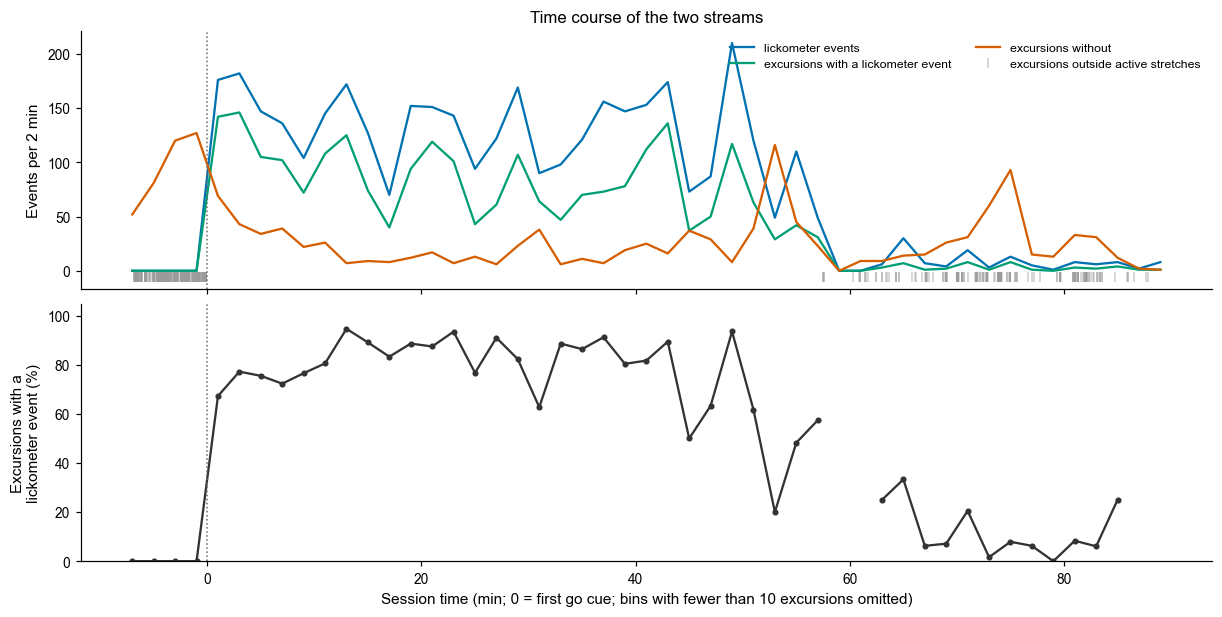

behavior_791691_2025-06-24_13-21-26: 3,928 kept excursions, 3,847 lickometer events.
Before the first lickometer event: 380 excursions, 380 without a lickometer event.
Outside active stretches (no lickometer event within 60 s on both sides): 648 excursions, 643 without a lickometer event, 42.9% of all unconfirmed excursions.


In [4]:
ex = kept[kept["session"] == EXAMPLE]
lk = lk_kept[EXAMPLE]
t_lo = min(ex["t_min"].min(), lk.min())
t_hi = max(ex["t_min"].max(), lk.max())
edges = np.arange(np.floor(t_lo / 120) * 120, t_hi + 120, 120)
mid = (edges[:-1] + edges[1:]) / 2 / 60

fig, axs = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, layout="constrained")
axs[0].plot(mid, np.histogram(lk, edges)[0], "-", color=C_CONF, label="lickometer events")
axs[0].plot(mid, np.histogram(ex.loc[ex["has_lk"], "t_min"], edges)[0], "-", color=PALETTE["baseline"],
            label="excursions with a lickometer event")
axs[0].plot(mid, np.histogram(ex.loc[~ex["has_lk"], "t_min"], edges)[0], "-", color=C_CAND,
            label="excursions without")
# Stretches the lickometer was not active: no event within ACTIVE_WINDOW on both sides.
inactive = ex.loc[~ex["lk_active"], "t_min"].to_numpy() / 60
if inactive.size:
    axs[0].plot(inactive, np.full(inactive.size, -6), "|", ms=6, color=C_GREY, alpha=0.5,
                label="excursions outside active stretches")
axs[0].axvline(0, color=PALETTE["neutral"], ls=":", lw=1)
axs[0].set_ylabel("Events per 2 min")
axs[0].set_title("Time course of the two streams")
axs[0].legend(fontsize=8, ncol=2, loc="upper right")

# Fraction of excursions with a lickometer event, per 2-minute bin.
n_all = np.histogram(ex["t_min"], edges)[0]
n_with = np.histogram(ex.loc[ex["has_lk"], "t_min"], edges)[0]
frac = np.where(n_all >= 10, n_with / np.maximum(n_all, 1), np.nan)
axs[1].plot(mid, 100 * frac, "o-", ms=3, color=PALETTE["all"])
axs[1].axvline(0, color=PALETTE["neutral"], ls=":", lw=1)
axs[1].set_ylim(0, 105)
axs[1].set_ylabel("Excursions with a\nlickometer event (%)")
axs[1].set_xlabel("Session time (min; 0 = first go cue; bins with fewer than 10 excursions omitted)")
for ax in axs:
    style_ax(ax)
save_fig(fig, "fig1_example_time_course", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

pre = ex[ex["t_min"] < lk.min()]
print("{}: {:,} kept excursions, {:,} lickometer events.".format(EXAMPLE, len(ex), lk.size))
print("Before the first lickometer event: {:,} excursions, {:,} without a lickometer event.".format(
    len(pre), int((~pre["has_lk"]).sum())))
print("Outside active stretches (no lickometer event within {:.0f} s on both sides): {:,} excursions, "
      "{:,} without a lickometer event, {:.1%} of all unconfirmed excursions.".format(
    ACTIVE_WINDOW, int((~ex["lk_active"]).sum()), int((~ex["lk_active"] & ~ex["has_lk"]).sum()),
    (~ex["lk_active"] & ~ex["has_lk"]).sum() / float((~ex["has_lk"]).sum())))

### Reading the output

The video starts about seven minutes before the first go cue and the lickometer stream starts
with it. Every excursion in those seven minutes is unconfirmed, whatever the tongue did. After
about 57 minutes the lickometer drops to a few events per minute while excursions continue, at a
lower rate, for another half hour; the fraction confirmed falls from around 80% in the middle of
the session to under 20% there. The excursions outside active stretches (grey ticks) are these
two periods plus a few pauses. They hold 643 of the 1,498 unconfirmed excursions.

Whether the lickometer was dead or the animal had stopped is not decidable from the lickometer
stream alone, and the pose stream in those stretches is examined below.

### Are the two streams on the same clock throughout?

A partial clock offset would send every excursion in the affected stretch to unconfirmed and
every lickometer event to unmatched, with the counts staying equal. The check: in each five-minute
block, shift the excursion times by a lag and count how many land within 30 ms of a lickometer
event; the lag that maximises the count is the block's offset.

In [5]:
def xcorr_peak(a, b, lags, tol=0.03):
    out = np.zeros(lags.size, dtype=int)
    for i, lag in enumerate(lags):
        off, _, _ = lq.nearest_offsets(a + lag, b)
        out[i] = int((np.abs(off) <= tol).sum())
    return out

lags = np.arange(-2.0, 2.001, 0.01)
rows = []
for lo in np.arange(edges[0], edges[-1], 300):
    a = ex.loc[(ex["t_min"] >= lo) & (ex["t_min"] < lo + 300), "t_min"].to_numpy()
    b = lk[(lk >= lo - 3) & (lk < lo + 303)]
    if a.size < 50 or b.size < 50:
        continue
    xc = xcorr_peak(a, b, lags)
    k = int(xc.argmax())
    rows.append({"block_start_min": lo / 60, "n_excursions": a.size, "n_lickometer": b.size,
                 "peak_lag_ms": 1000 * lags[k], "frac_at_peak": xc[k] / a.size,
                 "frac_at_zero": xc[np.abs(lags) < 1e-9][0] / a.size})
blocks = pd.DataFrame(rows)
display(blocks.round(3))
print("Peak lag across blocks with at least 50 events in each stream: {:+.0f} to {:+.0f} ms.".format(
    blocks["peak_lag_ms"].min(), blocks["peak_lag_ms"].max()))

,block_start_min,n_excursions,n_lickometer,peak_lag_ms,frac_at_peak,frac_at_zero
0,-3.0,403,189,-30.0,0.350,0.263
1,2.0,383,380,-30.0,0.747,0.585
2,7.0,314,344,-20.0,0.755,0.541
3,12.0,237,342,-30.0,0.911,0.713
4,17.0,268,345,-30.0,0.866,0.705
5,22.0,199,328,-30.0,0.884,0.744
6,27.0,264,300,-20.0,0.742,0.549
7,32.0,164,289,-30.0,0.817,0.610
8,37.0,284,413,-30.0,0.827,0.676
9,42.0,265,276,-20.0,0.698,0.540


Peak lag across blocks with at least 50 events in each stream: -30 to -20 ms.


### Reading the output

The peak lag is −20 or −30 ms in every block, including the last ones where under 10% of the
excursions match, and it equals the offset of confirmed contacts across the whole set (§4). The
two streams stay on one clock; the fall in the matched fraction is a fall in lickometer events,
with excursions continuing.

### How far the unconfirmed excursions are from any lickometer event

If unconfirmed excursions were licks the lickometer missed inside bouts, they would sit one
inter-lick interval from a lickometer event. The histogram is the time from each unconfirmed
excursion to the nearest lickometer event, for active stretches only.

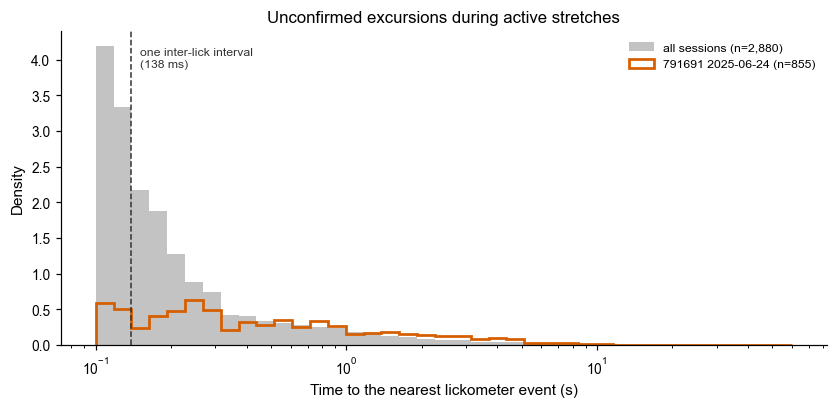

behavior_791691_2025-06-24_13-21-26: gap percentiles 10/25/50/75/90 = 0.30 / 0.80 / 2.22 / 4.63 / 10.66 s; within 2.5 intervals of a lickometer event on both sides: 0.6%


In [6]:
act = ex[ex["lk_active"]]
gap_un = act.loc[~act["has_lk"], "gap"].to_numpy()
gap_all_sessions = kept.loc[kept["lk_active"] & ~kept["has_lk"], "gap"].to_numpy()
mode_ms = 1000 * rhythm[EXAMPLE]

fig, ax = plt.subplots(figsize=(7.5, 3.6), layout="constrained")
bins = np.logspace(-1, np.log10(60), 40)
ax.hist(gap_all_sessions, bins=bins, density=True, color=C_GREY, alpha=0.6,
        label="all sessions (n={:,})".format(gap_all_sessions.size))
ax.hist(gap_un, bins=bins, density=True, histtype="step", lw=1.8, color=C_CAND,
        label="{} {} (n={:,})".format(EXAMPLE.split("_")[1], EXAMPLE.split("_")[2], gap_un.size))
ax.axvline(mode_ms / 1000, color=PALETTE["all"], ls="--", lw=1)
ax.annotate("one inter-lick interval\n({:.0f} ms)".format(mode_ms), xy=(mode_ms / 1000, 0.95),
            xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
            fontsize=8, va="top", color=PALETTE["all"])
ax.set_xscale("log")
ax.set_xlabel("Time to the nearest lickometer event (s)")
ax.set_ylabel("Density")
ax.set_title("Unconfirmed excursions during active stretches")
ax.legend(fontsize=8, loc="upper right")
style_ax(ax)
save_fig(fig, "fig2_gap_to_lickometer", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

q = np.percentile(gap_un, [10, 25, 50, 75, 90])
print("{}: gap percentiles 10/25/50/75/90 = {:.2f} / {:.2f} / {:.2f} / {:.2f} / {:.2f} s; "
      "within 2.5 intervals of a lickometer event on both sides: {:.1%}".format(
          EXAMPLE, *q, ((act["gap_prev"] <= 2.5 * mode_ms / 1000) & (act["gap_next"] <= 2.5 * mode_ms / 1000)
                        & ~act["has_lk"]).sum() / float(gap_un.size)))

### Reading the output

In the example session the median unconfirmed excursion is 2.2 s from the nearest lickometer
event, a quarter are within 0.8 s and a tenth within 0.3 s. Under 1% sit between two lickometer
events at bout spacing. These are excursions between bouts, when the lickometer recorded nothing
for seconds, with a smaller share at bout edges. Pooled over the set the distribution peaks
around one inter-lick interval instead, which is the skipped-beat population §5 returns to.

### What the distance trace looks like around them

Around each unconfirmed excursion, the tracked frames within ±1 s: how often the trace crosses
10 px per tracked second, and what fraction of tracked frames are within 15 px of the spout. A
licking tongue crosses the threshold at most eight times a second and spends most tracked frames
well outside 15 px, between protrusions.

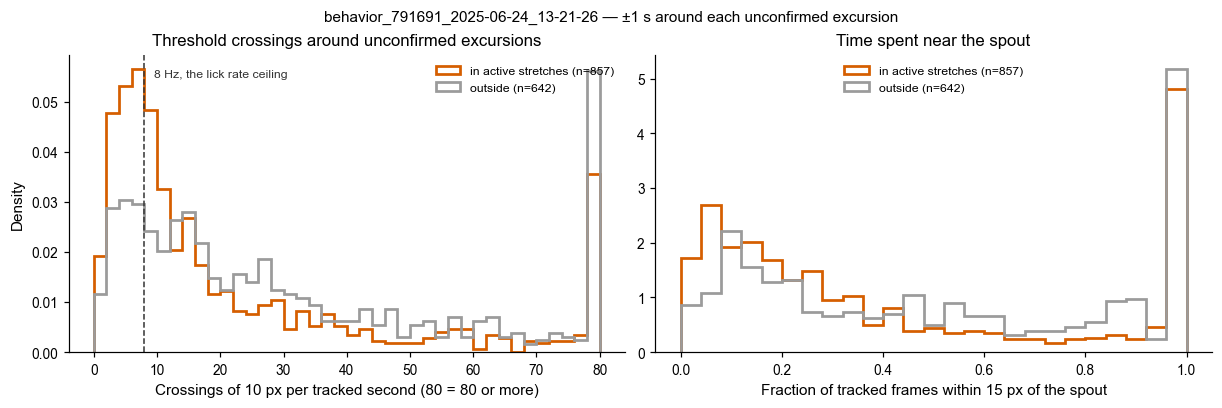

Median crossings per tracked second: 11 (active) / 22 (outside); above 8 Hz: 65% / 80%
Median fraction of tracked frames within 15 px: 0.27 (active) / 0.46 (outside)


In [7]:
if traces is None:
    print("[skip] no trace export in {}; §8 writes one on Code Ocean.".format(EVENTS_DIR))
else:
    def window_shape(w):
        d = w["spout_distance"].to_numpy()
        trk = ~np.isnan(d)
        below = d <= D0
        crossings = int((below[1:] & ~below[:-1]).sum() + below[0])
        dt = np.median(np.diff(w["time"].to_numpy())) if len(w) > 1 else np.nan
        return pd.Series({"crossings_per_s": crossings / max(trk.sum() * dt, 1e-3),
                          "tracked_frac": trk.mean(),
                          "within15_frac": float(np.mean(d[trk] <= 15)) if trk.any() else np.nan})

    shape = traces.groupby("fn_index")[["time", "spout_distance"]].apply(window_shape)
    shape["t"] = traces.groupby("fn_index")["fn_time"].first()
    lk_tr = lk_kept[traces["session"].iloc[0]]
    _, gp, gn = lq.nearest_offsets(shape["t"].to_numpy(), lk_tr)
    shape["active"] = (gp <= ACTIVE_WINDOW) & (gn <= ACTIVE_WINDOW)

    fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
    for act_flag, col, lbl in [(True, C_CAND, "in active stretches"), (False, C_GREY, "outside")]:
        sub = shape[shape["active"] == act_flag]
        axs[0].hist(sub["crossings_per_s"].clip(upper=80), bins=np.arange(0, 82, 2), density=True,
                    histtype="step", lw=1.8, color=col, label="{} (n={:,})".format(lbl, len(sub)))
        axs[1].hist(sub["within15_frac"].dropna(), bins=np.linspace(0, 1, 26), density=True,
                    histtype="step", lw=1.8, color=col, label="{} (n={:,})".format(lbl, len(sub)))
    axs[0].axvline(8, color=PALETTE["all"], ls="--", lw=1)
    axs[0].annotate("8 Hz, the lick rate ceiling", xy=(8, 0.95), xycoords=("data", "axes fraction"),
                    xytext=(6, 0), textcoords="offset points", fontsize=8, va="top", color=PALETTE["all"])
    axs[0].set_xlabel("Crossings of {} px per tracked second (80 = 80 or more)".format(D0))
    axs[0].set_ylabel("Density")
    axs[0].set_title("Threshold crossings around unconfirmed excursions")
    axs[0].legend(fontsize=8, loc="upper right")
    axs[1].set_xlabel("Fraction of tracked frames within 15 px of the spout")
    axs[1].set_title("Time spent near the spout")
    axs[1].legend(fontsize=8, loc="upper center")
    for ax in axs:
        style_ax(ax)
    fig.suptitle("{} — ±1 s around each unconfirmed excursion".format(traces["session"].iloc[0]), fontsize=10)
    save_fig(fig, "fig3_trace_shape", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Median crossings per tracked second: {:.0f} (active) / {:.0f} (outside); above 8 Hz: {:.0%} / {:.0%}".format(
        shape.loc[shape["active"], "crossings_per_s"].median(), shape.loc[~shape["active"], "crossings_per_s"].median(),
        (shape.loc[shape["active"], "crossings_per_s"] > 8).mean(), (shape.loc[~shape["active"], "crossings_per_s"] > 8).mean()))
    print("Median fraction of tracked frames within 15 px: {:.2f} (active) / {:.2f} (outside)".format(
        shape.loc[shape["active"], "within15_frac"].median(), shape.loc[~shape["active"], "within15_frac"].median()))

### Reading the output

Around most unconfirmed excursions the trace crosses 10 px more often than a tongue can lick:
the median is 11 crossings per tracked second in active stretches and 22 outside them, with
two thirds and four fifths of the windows above 8 per second. Outside active stretches the
keypoint also spends close to half of its tracked frames within 15 px of the spout, and a fifth of
the windows have it there the whole time. This is a keypoint hovering at the threshold, entering
and leaving the 10 px ball on jitter, which yields one excursion per re-entry. The excursions it
produces are shallow and short, which is what §3 measures.

What `val_04` takes from this section: excursions are scored only while the lickometer was
active, with an event within 60 s on both sides. That removes the pre-trial and post-session
stretches, where a miss cannot be distinguished from the animal not licking. The trade-off is
that a lickometer dead for over a minute during trials is invisible to the miss rate; `val_04`'s
dropout scan covers that case separately.

## 3. Depth and dwell of confirmed and unconfirmed excursions

Pooled over all sessions and active stretches: the fraction of kept excursions with no
lickometer event, as a function of how close the keypoint came to the spout and how many frames
it stayed within 10 px.

/Users/mib/Documents/Code/kinematics_analysis/.venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/mib/Documents/Code/kinematics_analysis/.venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


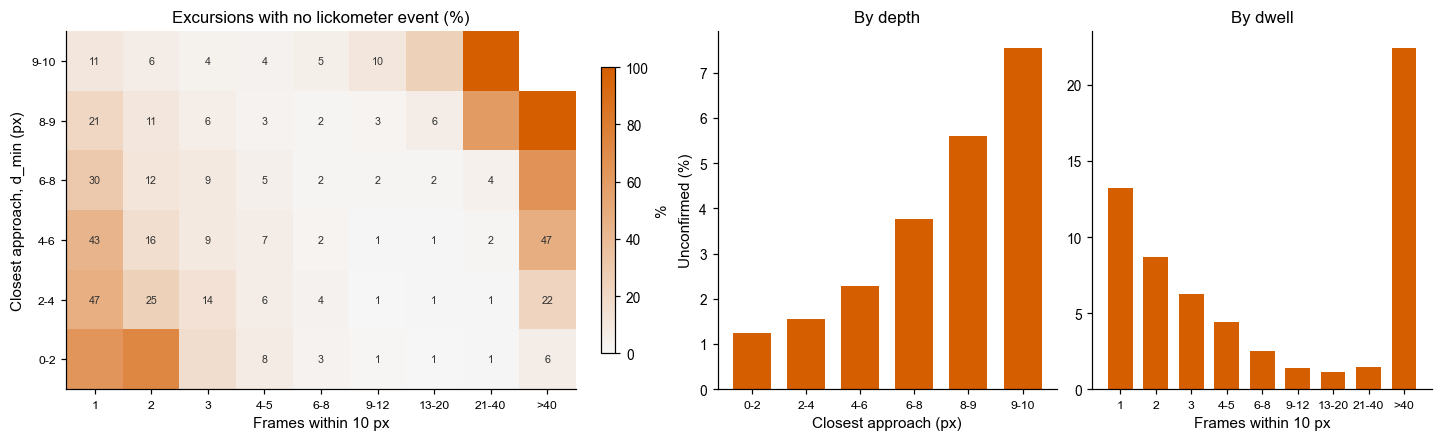

78,220 kept excursions in active stretches, 3.7% unconfirmed overall.


In [8]:
act_all = kept[kept["lk_active"]].copy()
act_all["unconfirmed"] = ~act_all["has_lk"]
d_bins = [0, 2, 4, 6, 8, 9, 10]
f_bins = [0, 1, 2, 3, 5, 8, 12, 20, 40, 10000]
f_labels = ["1", "2", "3", "4-5", "6-8", "9-12", "13-20", "21-40", ">40"]
act_all["dbin"] = pd.cut(act_all["d_min"], d_bins, include_lowest=True)
act_all["fbin"] = pd.cut(act_all["n_frames"], f_bins, labels=f_labels)
grid = act_all.pivot_table(index="dbin", columns="fbin", values="unconfirmed", aggfunc="mean", observed=False)
counts = act_all.pivot_table(index="dbin", columns="fbin", values="unconfirmed", aggfunc="size", observed=False)

cmap = LinearSegmentedColormap.from_list("cand", ["#f7f7f7", C_CAND])
fig, axs = plt.subplots(1, 3, figsize=(13, 3.9), layout="constrained",
                        gridspec_kw={"width_ratios": [1.5, 1, 1]})
im = axs[0].imshow(100 * grid.to_numpy(), cmap=cmap, vmin=0, vmax=100, aspect="auto", origin="lower")
axs[0].set_xticks(range(len(f_labels)))
axs[0].set_xticklabels(f_labels, fontsize=8)
axs[0].set_yticks(range(len(grid.index)))
axs[0].set_yticklabels(["{:g}-{:g}".format(i.left if i.left > 0 else 0, i.right) for i in grid.index], fontsize=8)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v, n = grid.iloc[i, j], counts.iloc[i, j]
        if n >= 30:
            axs[0].text(j, i, "{:.0f}".format(100 * v), ha="center", va="center", fontsize=7,
                        color="white" if v > 0.5 else PALETTE["all"])
axs[0].set_xlabel("Frames within 10 px")
axs[0].set_ylabel("Closest approach, d_min (px)")
axs[0].set_title("Excursions with no lickometer event (%)")
fig.colorbar(im, ax=axs[0], shrink=0.8, label="%")

by_d = act_all.groupby("dbin", observed=False)["unconfirmed"].mean()
axs[1].bar(range(len(by_d)), 100 * by_d, color=C_CAND, width=0.7)
axs[1].set_xticks(range(len(by_d)))
axs[1].set_xticklabels(["{:g}-{:g}".format(i.left if i.left > 0 else 0, i.right) for i in by_d.index], fontsize=8)
axs[1].set_xlabel("Closest approach (px)")
axs[1].set_ylabel("Unconfirmed (%)")
axs[1].set_title("By depth")

by_f = act_all.groupby("fbin", observed=False)["unconfirmed"].mean()
axs[2].bar(range(len(by_f)), 100 * by_f, color=C_CAND, width=0.7)
axs[2].set_xticks(range(len(by_f)))
axs[2].set_xticklabels(f_labels, fontsize=8)
axs[2].set_xlabel("Frames within 10 px")
axs[2].set_title("By dwell")
for ax in axs[1:]:
    style_ax(ax)
save_fig(fig, "fig4_depth_dwell", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
print("{:,} kept excursions in active stretches, {:.1%} unconfirmed overall.".format(
    len(act_all), act_all["unconfirmed"].mean()))

### Reading the output

During active stretches 3.7% of kept excursions have no lickometer event. The fraction rises
from 1.2% for excursions that reach within 2 px of the spout to 7.5% for those that only reach 9
to 10 px, and from 1.2% for excursions lasting 13 to 20 frames to 13% for single-frame ones and
22% for those over 40 frames. The two combine: a one-frame excursion is unconfirmed 11% to 47% of
the time at any depth, an excursion of more than 40 frames at 8 px or beyond is unconfirmed
almost always, and an excursion of 9 to 40 frames reaching within 6 px is unconfirmed 1% to 2% of
the time. The long shallow cells are the hovering keypoint from §2; the one- and two-frame cells
are grazing approaches and flickers. Neither looks like a confirmed contact, and together they
hold most of the unconfirmed population.

### Neighbouring excursions

The number of other excursions within ±250 ms, counted before the refractory filter. A lick in a
bout has one or two; a keypoint jittering at the threshold has many; a single flicker has none.

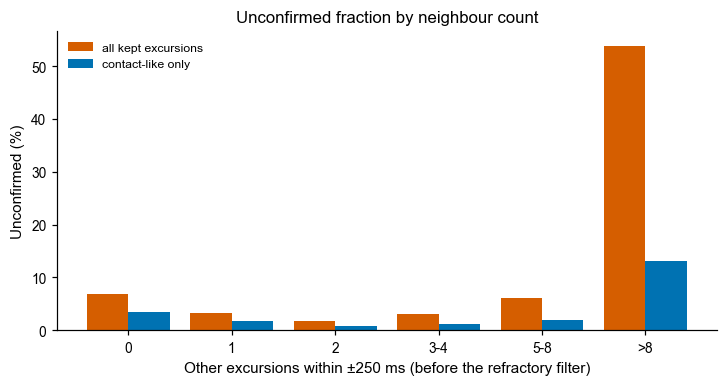

,unconfirmed_all,n_all,unconfirmed_contact,n_contact
sbin,,,,
0,0.068,14976,0.034,6206
1,0.033,22736,0.017,10754
2,0.017,25310,0.007,13750
3-4,0.031,11447,0.012,5276
5-8,0.061,3573,0.020,1538
>8,0.539,178,0.130,23


In [9]:
sib_bins = [-1, 0, 1, 2, 4, 8, 1000]
sib_labels = ["0", "1", "2", "3-4", "5-8", ">8"]
act_all["sbin"] = pd.cut(act_all["n_siblings"], sib_bins, labels=sib_labels)
by_s = act_all.groupby("sbin", observed=False)["unconfirmed"].agg(["mean", "size"])
by_s_contact = act_all[act_all["contact"]].groupby("sbin", observed=False)["unconfirmed"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(6.5, 3.4), layout="constrained")
x = np.arange(len(by_s))
ax.bar(x - 0.2, 100 * by_s["mean"], width=0.4, color=C_CAND, label="all kept excursions")
ax.bar(x + 0.2, 100 * by_s_contact["mean"], width=0.4, color=C_CONF, label="contact-like only")
ax.set_xticks(x)
ax.set_xticklabels(sib_labels)
ax.set_xlabel("Other excursions within ±250 ms (before the refractory filter)")
ax.set_ylabel("Unconfirmed (%)")
ax.set_title("Unconfirmed fraction by neighbour count")
ax.legend(fontsize=8)
style_ax(ax)
save_fig(fig, "fig5_siblings", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
display(pd.concat([by_s.rename(columns={"mean": "unconfirmed_all", "size": "n_all"}),
                   by_s_contact.rename(columns={"mean": "unconfirmed_contact", "size": "n_contact"})],
                  axis=1).round(3))

### Reading the output

Excursions with no neighbour and excursions with more than eight are unconfirmed far more often
than those with one to four, for all excursions. Once the depth and dwell criteria are applied the
neighbour count carries little extra: the contact-like excursions are unconfirmed at a few
percent whatever their neighbour count, apart from the small group with more than eight. The
contact-like definition already removes most of what the neighbour count would catch, so
`val_04` does not use it as a criterion.

### Why the reference is per session

The closest approach and dwell of confirmed contacts differ between sessions, because the cameras
and spout keypoints differ. The figure shows each session's median confirmed approach against
its 25th percentile dwell.

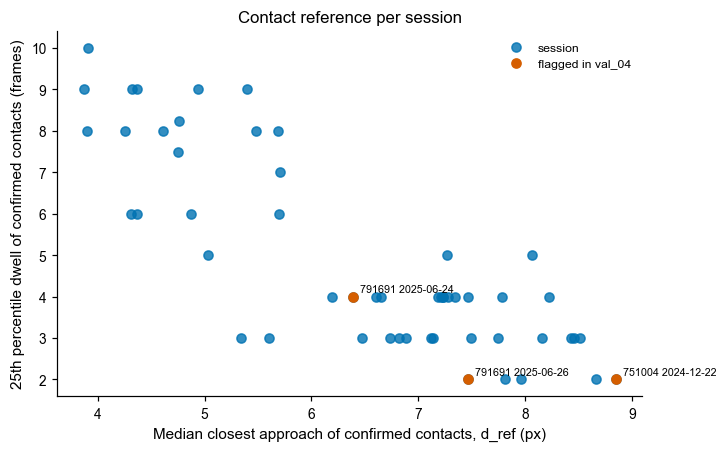

With a fixed rule (d_min <= 5 px and >= 3 frames) the contact-like count per session runs from 17 to 1,965; the per-session reference gives 70 to 1,649.


In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4), layout="constrained")
ax.plot(ref["d_ref"], ref["frames_lo"], "o", ms=6, alpha=0.8, color=C_CONF, label="session")
flag_idx = summary.index[summary["flag_session"]]
ax.plot(ref.loc[flag_idx, "d_ref"], ref.loc[flag_idx, "frames_lo"], "o", ms=6, color=C_CAND,
        label="flagged in val_04")
for sess in flag_idx:
    ax.annotate(sess.split("_")[1] + " " + sess.split("_")[2],
                xy=(ref.loc[sess, "d_ref"], ref.loc[sess, "frames_lo"]), xytext=(5, 3),
                textcoords="offset points", fontsize=7)
ax.set_xlabel("Median closest approach of confirmed contacts, d_ref (px)")
ax.set_ylabel("25th percentile dwell of confirmed contacts (frames)")
ax.set_title("Contact reference per session")
ax.legend(fontsize=8, loc="upper right")
style_ax(ax)
save_fig(fig, "fig6_reference_by_session", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

fixed = kept[kept["lk_active"]].copy()
fixed["contact_fixed"] = (fixed["d_min"] <= 5) & (fixed["n_frames"] >= 3)
n_fixed = fixed.groupby("session")["contact_fixed"].sum()
print("With a fixed rule (d_min <= 5 px and >= 3 frames) the contact-like count per session runs "
      "from {:,} to {:,}; the per-session reference gives {:,} to {:,}.".format(
          int(n_fixed.min()), int(n_fixed.max()),
          int(summary["n_contact"].min()), int(summary["n_contact"].max())))

### Reading the output

The median confirmed approach runs from 3.9 to 8.8 px and the dwell floor from 2 to 10 frames,
and the two move together: sessions where the keypoint gets closer also see it stay longer. In
`751004` a confirmed contact rarely brings the keypoint within 8 px of the spout keypoint, so a
fixed 5 px rule would leave that animal with a few dozen contact-like excursions per session and
score it on almost nothing. The per-session reference keeps roughly half of each session's
confirmed contacts by construction, so the miss rate compares like with like.

What `val_04` takes from this section: contact-like means reaching the session's median
confirmed approach and dwelling between its 25th percentile and twice its 95th.

## 4. Matching the two streams

Four choices: which moment of the excursion to time it by, how wide the window is, whether
events are paired one to one, and how to detect a session whose two clocks disagree.

### Onset or closest approach

The library's `detect_licks` timestamps the frame the tongue enters the 10 px ball. The lickometer
fires at contact. The lag between them depends on approach speed, so a slow approach could push a
real contact out of the window when timed from onset.

In [11]:
ev_on, ref_on, summ_on, _, _ = run_pipeline(pose, licko, time_col="t_onset")
cmp = pd.DataFrame({"closest_approach": summary["miss_rate"], "onset": summ_on["miss_rate"]})
lag = 1000 * (kept["t_min"] - kept["t_onset"])
print("Onset to closest approach across all kept excursions: median {:.0f} ms, 95th percentile {:.0f} ms.".format(
    lag.median(), lag.quantile(0.95)))
print("Miss rate timed from the onset vs from the closest approach: max absolute difference {:.2f} points; "
      "Spearman rank correlation {:.3f}.".format(
          100 * (cmp["onset"] - cmp["closest_approach"]).abs().max(),
          cmp.corr("spearman").iloc[0, 1]))
display(cmp.loc[summary.index[:6]].round(4))

Onset to closest approach across all kept excursions: median 6 ms, 95th percentile 26 ms.
Miss rate timed from the onset vs from the closest approach: max absolute difference 1.91 points; Spearman rank correlation 0.987.


,closest_approach,onset
session,,
behavior_763590_2025-05-02_11-07-07,0.3286,0.3143
behavior_763590_2025-05-01_10-59-16,0.1649,0.1458
behavior_791691_2025-06-26_13-39-22,0.1011,0.1034
behavior_791691_2025-06-24_13-21-26,0.0924,0.0971
behavior_751004_2024-12-22_13-09-11,0.0826,0.0826
behavior_784806_2025-06-18_13-39-50,0.0422,0.0437


### Reading the output

Closest approach follows onset by a median of 6 ms and by under 30 ms in 95% of excursions. The
two timings give miss rates within half a point of each other in every session except the two
`763590` days, where the difference reaches two points, and the ranking is the same (rank
correlation 0.99). `val_04` times from closest approach because it is the moment nearest to
contact.

### Window width, and the offset between the streams

For confirmed contacts the lickometer event comes a little before the closest approach. The
figure shows each session's median offset with its 5th to 95th percentile range, and how the miss
rate responds to the window width.

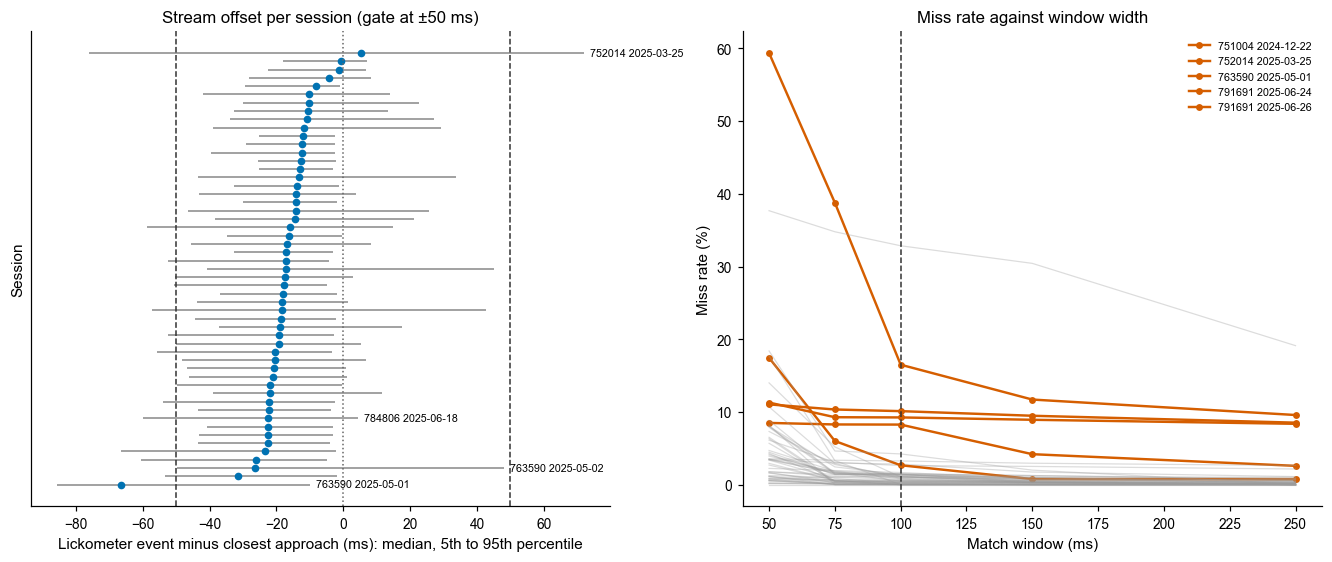

Median offset across sessions: -17 ms (range -66 to +5); interquartile range median 17 ms (max 36).


,offset_median_ms,offset_p5_ms,offset_p95_ms,offset_iqr_ms
session,,,,
behavior_763590_2025-05-01_10-59-16,-66.4,-85.5,-9.9,36.3
behavior_763590_2025-05-02_11-07-07,-26.3,-49.6,47.9,33.0
behavior_784806_2025-06-18_13-39-50,-22.5,-59.8,4.5,30.7
behavior_752014_2025-03-25_12-09-16,5.3,-76.1,72.0,33.3


In [12]:
al = summary[["offset_median_ms", "offset_p5_ms", "offset_p95_ms", "offset_iqr_ms"]].sort_values("offset_median_ms")

fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained", gridspec_kw={"width_ratios": [1, 1]})
y = np.arange(len(al))
axs[0].hlines(y, al["offset_p5_ms"], al["offset_p95_ms"], color=C_GREY, lw=1.2)
axs[0].plot(al["offset_median_ms"], y, "o", ms=4, color=C_CONF)
axs[0].axvline(0, color=PALETTE["neutral"], ls=":", lw=1)
for s_ in (-MAX_OFFSET_MS, MAX_OFFSET_MS):
    axs[0].axvline(s_, color=PALETTE["all"], ls="--", lw=1)
for i, (sess, r) in enumerate(al.iterrows()):
    if abs(r["offset_median_ms"]) > MAX_OFFSET_MS or r["offset_iqr_ms"] > 30:
        axs[0].annotate(sess.split("_")[1] + " " + sess.split("_")[2], xy=(r["offset_p95_ms"], i),
                        xytext=(4, 0), textcoords="offset points", va="center", fontsize=7)
axs[0].set_yticks([])
axs[0].set_xlabel("Lickometer event minus closest approach (ms): median, 5th to 95th percentile")
axs[0].set_ylabel("Session")
axs[0].set_title("Stream offset per session (gate at ±{:.0f} ms)".format(MAX_OFFSET_MS))

windows = [0.05, 0.075, 0.1, 0.15, 0.25]
sweep = {}
for w in windows:
    _, _, s_w, _, _ = run_pipeline(pose, licko, match_window=w)
    sweep[w] = s_w["miss_rate"]
sweep = pd.DataFrame(sweep)
hot = set(summary.index[summary["flag_session"]]) | {"behavior_763590_2025-05-01_10-59-16",
                                                      "behavior_752014_2025-03-25_12-09-16"}
for sess, row in sweep.iterrows():
    is_hot = sess in hot
    axs[1].plot([1000 * w for w in windows], 100 * row.to_numpy(), "-o" if is_hot else "-",
                ms=3.5, lw=1.6 if is_hot else 0.8, alpha=1 if is_hot else 0.35,
                color=C_CAND if is_hot else C_GREY,
                label=sess.split("_")[1] + " " + sess.split("_")[2] if is_hot else None)
axs[1].axvline(1000 * MATCH_WINDOW, color=PALETTE["all"], ls="--", lw=1)
axs[1].set_xlabel("Match window (ms)")
axs[1].set_ylabel("Miss rate (%)")
axs[1].set_title("Miss rate against window width")
axs[1].legend(fontsize=7, loc="upper right")
for ax in axs:
    style_ax(ax)
save_fig(fig, "fig7_offset_and_window", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Median offset across sessions: {:+.0f} ms (range {:+.0f} to {:+.0f}); interquartile range median {:.0f} ms (max {:.0f}).".format(
    al["offset_median_ms"].median(), al["offset_median_ms"].min(), al["offset_median_ms"].max(),
    al["offset_iqr_ms"].median(), al["offset_iqr_ms"].max()))
display(al[(al["offset_median_ms"].abs() > MAX_OFFSET_MS) | (al["offset_iqr_ms"] > 30)].round(1))

### Reading the output

The lickometer fires 10 to 30 ms before the closest approach in nearly every session, with an
interquartile range of 6 to 36 ms. A 100 ms window is three to five times that spread, and
widening it to 150 or 250 ms lowers the miss rate by well under a point in the flagged sessions.
Two sessions stand apart. `763590 2025-05-01` has a median offset of −66 ms, so a fifth of its
confirmed contacts sit within 15 ms of the window edge, which inflates its miss rate; it is
gated on the offset. `752014 2025-03-25` is centred near zero but with a 33 ms interquartile range
and a tail past +70 ms, so its rate falls from 17% at a 50 ms window to 2.7% at 100 ms and 0.9%
at 150 ms; it has 263 contact-like excursions and stays below the flag from 100 ms on.

What `val_04` takes from this section: a 100 ms window, and a gate at |median offset| > 50 ms.

### One-to-one pairing or any event within the window

The previous version of `val_04` paired events one to one with the library's greedy matcher and
counted unpaired excursions. Two properties of that scheme were verified directly. First, the
greedy matcher is optimal: an order-preserving maximum matching finds the same number of pairs on
every session's real event lists (checked below) as it did on ~9,400 synthetic trials. Second,
one-to-one pairing forces a floor of `1 − n_lickometer / n_excursions` on the miss rate whenever
excursions outnumber lickometer events, and it leaves an excursion unpaired whenever the
lickometer event inside its window was claimed by a neighbouring excursion. Neither is a property
of the lickometer.

In [13]:
rows = []
for sess, g in kept.groupby("session"):
    a = g["t_min"].to_numpy()
    b = lk_kept[sess]
    am, _ = lq.match_greedy(a, b, MATCH_WINDOW)
    n_opt = lq.match_optimal(a, b, MATCH_WINDOW)
    # Unpaired by the one-to-one matcher, yet with a lickometer event inside the window.
    order = np.argsort(a)
    has = g["has_lk"].to_numpy()[order]
    rows.append({"session": sess, "n_excursions": a.size, "n_lickometer": b.size,
                 "greedy_pairs": int(am.sum()), "optimal_pairs": n_opt,
                 "unpaired_with_event_in_window": int((~am & has).sum()),
                 "floor": max(0.0, 1 - b.size / float(a.size))})
pairing = pd.DataFrame(rows).set_index("session")
print("Sessions where the optimum finds more pairs than greedy: {}".format(
    int((pairing["optimal_pairs"] > pairing["greedy_pairs"]).sum())))
print("Excursions left unpaired with a lickometer event inside their window: {:,} across all sessions, "
      "{:.1%} of what the one-to-one scheme called unmatched.".format(
          int(pairing["unpaired_with_event_in_window"].sum()),
          pairing["unpaired_with_event_in_window"].sum() / float((pairing["n_excursions"] - pairing["greedy_pairs"]).sum())))
display(pairing.sort_values("unpaired_with_event_in_window", ascending=False).head(6).round(3))

Sessions where the optimum finds more pairs than greedy: 0
Excursions left unpaired with a lickometer event inside their window: 271 across all sessions, 5.4% of what the one-to-one scheme called unmatched.


,n_excursions,n_lickometer,greedy_pairs,optimal_pairs,unpaired_with_event_in_window,floor
session,,,,,,
behavior_752014_2025-03-25_12-09-16,554,836,465,465,69,0.0
behavior_758018_2025-03-19_11-16-41,2932,3944,2681,2681,69,0.0
behavior_758018_2025-03-20_11-53-02,2795,4478,2681,2681,27,0.0
behavior_751769_2025-01-17_11-37-35,2658,3960,2612,2612,18,0.0
behavior_751766_2025-02-11_11-53-32,2162,4207,2100,2100,15,0.0
behavior_751766_2025-02-15_12-08-11,1483,4667,1446,1446,15,0.0


### Reading the output

Greedy pairing is optimal on every session. Even so, 271 excursions across the set were counted
as unmatched while a lickometer event sat inside their window; 69 of the 89 in `752014
2025-03-25` were of this kind, and 69 of the 251 in `758018 2025-03-19`. Scoring each excursion by whether any lickometer event falls in its
window removes both the floor and the claiming effect, and it is what `val_04` does. The cost is
that a burst of two excursions within 100 ms of one lickometer event both count as confirmed; the
refractory filter keeps that to excursions more than 100 ms apart, and §3 shows the second of such
a pair is usually shallow.

## 5. Lickometer context and the skipped-beat test

Where a candidate sits relative to the lickometer stream says what kind of failure it could be.
The lickometer's own rhythm gives an independent check: within a bout, an interval about twice
the modal one is a skipped beat, and a pose excursion in the middle of it says the tongue was at
the spout. The same test on ordinary single intervals gives the rate at which an excursion is found
mid-interval when no lick was skipped.

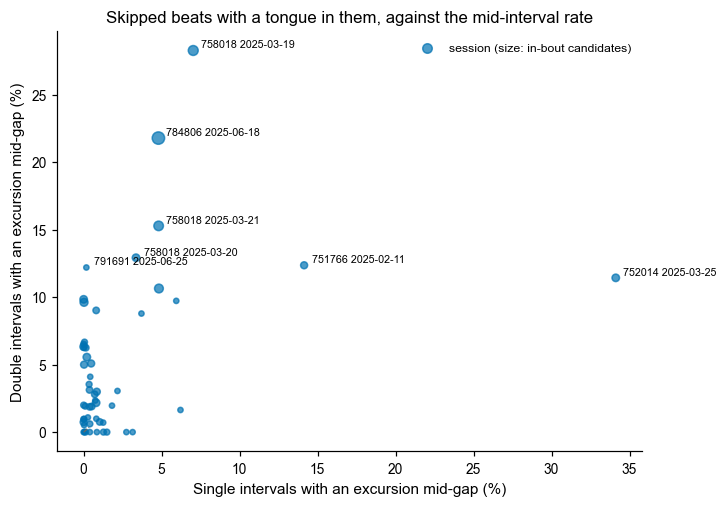

,n_lickometer,ili_mode_ms,n_double,n_double_with_pose,skipped_beat_frac,n_single,single_interval_frac,n_in_bout,n_candidate,miss_rate,in_bout_per_1000
session,,,,,,,,,,,
behavior_758018_2025-03-19_11-16-41,3944,181.824,237,67,0.283,2135,0.070,10,15,0.011,2.535
behavior_784806_2025-06-18_13-39-50,3212,158.016,101,22,0.218,2170,0.048,18,51,0.042,5.604
behavior_758018_2025-03-21_11-00-31,4135,185.824,216,33,0.153,2413,0.048,9,11,0.009,2.177
behavior_758018_2025-03-20_11-53-02,4478,181.504,209,27,0.129,2682,0.034,4,18,0.013,0.893
behavior_751766_2025-02-11_11-53-32,4207,176.000,89,11,0.124,2816,0.141,3,11,0.010,0.713
behavior_791691_2025-06-25_14-05-48,3087,138.528,41,5,0.122,2311,0.002,0,5,0.005,0.000
behavior_752014_2025-03-25_12-09-16,836,192.192,35,4,0.114,384,0.341,4,7,0.027,4.785
behavior_763590_2025-05-01_10-59-16,1903,181.664,47,5,0.106,1264,0.048,7,16,0.165,3.678


In [14]:
sb = summary[["n_lickometer", "ili_mode_ms", "n_double", "n_double_with_pose", "skipped_beat_frac",
              "n_single", "single_interval_frac", "n_in_bout", "n_candidate", "miss_rate"]].copy()
sb["in_bout_per_1000"] = 1000 * sb["n_in_bout"] / sb["n_lickometer"]

fig, ax = plt.subplots(figsize=(6.5, 4.5), layout="constrained")
ax.plot([0, 0.35], [0, 0.35], ls="--", lw=0.8, color=PALETTE["neutral"])
ax.scatter(100 * sb["single_interval_frac"], 100 * sb["skipped_beat_frac"],
           s=12 + 3 * sb["n_in_bout"], color=C_CONF, alpha=0.7, label="session (size: in-bout candidates)")
for sess, r in sb.iterrows():
    if r["skipped_beat_frac"] > 0.12 or r["single_interval_frac"] > 0.1:
        ax.annotate(sess.split("_")[1] + " " + sess.split("_")[2],
                    xy=(100 * r["single_interval_frac"], 100 * r["skipped_beat_frac"]),
                    xytext=(5, 2), textcoords="offset points", fontsize=7)
ax.set_xlabel("Single intervals with an excursion mid-gap (%)")
ax.set_ylabel("Double intervals with an excursion mid-gap (%)")
ax.set_title("Skipped beats with a tongue in them, against the mid-interval rate")
ax.legend(fontsize=8, loc="upper right")
style_ax(ax)
save_fig(fig, "fig8_skipped_beats", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
display(sb.sort_values("skipped_beat_frac", ascending=False).head(8).round(3))

### Reading the output

In most sessions 0 to 6% of double intervals hold an excursion, against 0 to 2% of single
intervals. `758018` stands out on all three days, at 28%, 15% and 13%, with `784806 2025-06-18`
at 22%. `752014 2025-03-25` has 34% of its single intervals holding an excursion, which is the
timing jitter from §4 putting excursions mid-interval, so its skipped-beat count means little.

### Are the excursions in skipped beats contact-like?

If a skipped beat is a missed contact, the excursion in it should look like the session's
confirmed contacts. If the animal made a shorter protrusion that did not reach the spout, it
should be shallower and briefer.

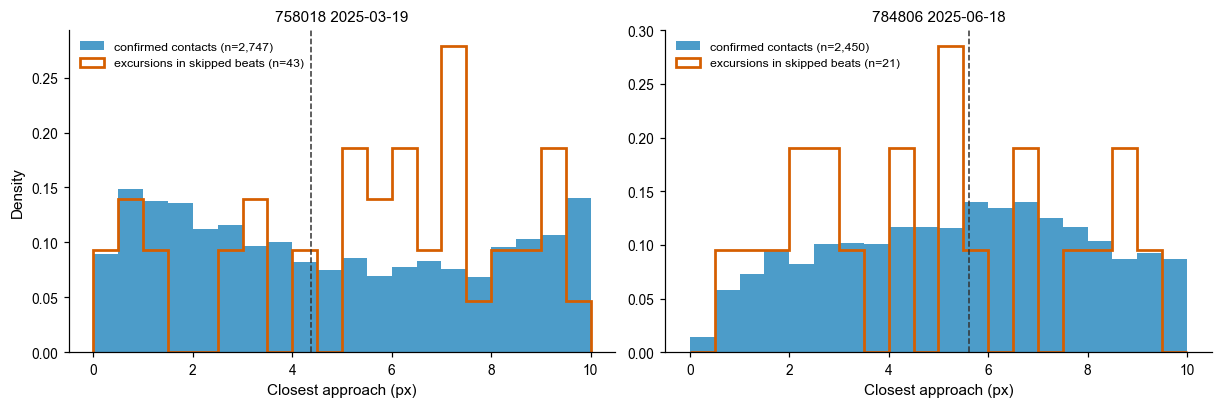

,n_in_gap,d_min_median_in_gap,d_min_median_confirmed,frames_median_in_gap,frames_median_confirmed,contact_like_frac
session,,,,,,
behavior_758018_2025-03-19_11-16-41,43,6.18,4.37,7.0,16.0,0.23
behavior_784806_2025-06-18_13-39-50,21,5.05,5.59,13.0,5.0,0.62


In [15]:
def in_gap_excursions(sess, factor=(1.6, 2.4)):
    lk_s = lk_kept[sess]
    mode = rhythm[sess]
    g = events[events["session"] == sess].sort_values("t_min")
    tm = g["t_min"].to_numpy()
    ili = np.diff(lk_s)
    out = []
    for j in np.flatnonzero((ili > factor[0] * mode) & (ili < factor[1] * mode)):
        a, b = lk_s[j], lk_s[j + 1]
        lo, hi = a + 0.25 * (b - a), b - 0.25 * (b - a)
        k0, k1 = np.searchsorted(tm, [lo, hi])
        if k1 > k0:
            sub = g.iloc[k0:k1]
            out.append(sub.iloc[int(sub["d_min"].argmin())])
    return pd.DataFrame(out)

show = ["behavior_758018_2025-03-19_11-16-41", "behavior_784806_2025-06-18_13-39-50"]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
rows = []
for ax, sess in zip(axs, show):
    gap_ex = in_gap_excursions(sess)
    conf_s = kept[(kept["session"] == sess) & kept["lk_active"] & kept["has_lk"]]
    bins = np.arange(0, D0 + 0.5, 0.5)
    ax.hist(conf_s["d_min"], bins=bins, density=True, color=C_CONF, alpha=0.7,
            label="confirmed contacts (n={:,})".format(len(conf_s)))
    ax.hist(gap_ex["d_min"], bins=bins, density=True, histtype="step", lw=1.8, color=C_CAND,
            label="excursions in skipped beats (n={})".format(len(gap_ex)))
    ax.axvline(ref.loc[sess, "d_ref"], color=PALETTE["all"], ls="--", lw=1)
    ax.set_xlabel("Closest approach (px)")
    ax.set_title(sess.split("_")[1] + " " + sess.split("_")[2], fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    style_ax(ax)
    r = ref.loc[sess]
    rows.append({"session": sess, "n_in_gap": len(gap_ex),
                 "d_min_median_in_gap": gap_ex["d_min"].median(), "d_min_median_confirmed": conf_s["d_min"].median(),
                 "frames_median_in_gap": gap_ex["n_frames"].median(), "frames_median_confirmed": conf_s["n_frames"].median(),
                 "contact_like_frac": ((gap_ex["d_min"] <= r["d_ref"]) & (gap_ex["n_frames"] >= r["frames_lo"])
                                       & (gap_ex["n_frames"] <= r["frames_hi"])).mean()})
axs[0].set_ylabel("Density")
save_fig(fig, "fig9_in_gap_depth", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
display(pd.DataFrame(rows).set_index("session").round(2))

### Reading the output

In `758018 2025-03-19` the excursions inside skipped beats reach a median of 6.2 px against
4.3 px for confirmed contacts, and last 7 frames against 16; about a quarter are contact-like. In
`784806 2025-06-18` they reach 5.0 px against 5.6 and last longer than confirmed contacts, and
most are contact-like. The same lickometer pattern, a skipped beat with a tongue in it, covers two
things: in `758018` mostly a shorter protrusion that did not reach the spout, in `784806` mostly
a contact the lickometer did not register.

What `val_04` takes from this section: candidates are split by lickometer context, in-bout
candidates are the ones that correspond to the issue's description, and the skipped-beat
fraction and its single-interval control are carried in the QC table as a check that does not
depend on the pose thresholds.

## 6. Sensitivity of the ranking to the choices

Each parameter is varied on its own with the others at the `val_04` defaults. For each setting:
the rank correlation of the per-session miss rate with the default, and which sessions are
flagged.

In [16]:
variants = [
    ("default", {}),
    ("depth quantile 0.75", {"depth_q": 0.75}),
    ("no depth criterion", {"depth_q": 1.0}),
    ("no dwell floor", {"dwell_q": 0.0}),
    ("dwell quantile 0.5", {"dwell_q": 0.5}),
    ("no dwell ceiling", {"dwell_max_factor": 1e6}),
    ("active window 30 s", {"active_window": 30.0}),
    ("active window 120 s", {"active_window": 120.0}),
    ("active window 600 s", {"active_window": 600.0}),
    ("match window 50 ms", {"match_window": 0.05}),
    ("match window 150 ms", {"match_window": 0.15}),
    ("refractory 50 ms", {"t_refractory": 0.05}),
]
rows = []
base = summary["miss_rate"]
for name, kw in variants:
    _, _, s_v, _, _ = run_pipeline(pose, licko, **kw)
    s_v = s_v.reindex(base.index)
    flagged = [s.split("_")[1] + " " + s.split("_")[2] for s in s_v.index[s_v["flag_session"]]]
    rows.append({"variant": name, "spearman_vs_default": s_v["miss_rate"].corr(base, method="spearman"),
                 "median_miss_rate": s_v["miss_rate"].median(),
                 "miss_rate_791691_06-24": s_v.loc[EXAMPLE, "miss_rate"],
                 "n_flagged": len(flagged), "flagged": ", ".join(flagged)})
sens = pd.DataFrame(rows).set_index("variant")
pd.set_option("display.max_colwidth", 120)
display(sens.round(3))

raw = 1.0 - kept.groupby("session")["has_lk"].mean()
print("Rank correlation between the raw disagreement (kept excursions without a lickometer event, "
      "no active or contact-like filter) and the default miss rate: {:.2f}".format(
          raw.reindex(base.index).corr(base, method="spearman")))

,spearman_vs_default,median_miss_rate,miss_rate_791691_06-24,n_flagged,flagged
variant,,,,,
default,1.000,0.008,0.092,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"
depth quantile 0.75,0.953,0.009,0.118,2,"791691 2025-06-26, 791691 2025-06-24"
no depth criterion,0.935,0.009,0.139,2,"791691 2025-06-26, 791691 2025-06-24"
no dwell floor,0.939,0.012,0.113,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"
dwell quantile 0.5,0.953,0.005,0.073,2,"791691 2025-06-26, 791691 2025-06-24"
no dwell ceiling,0.997,0.008,0.105,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"
active window 30 s,0.993,0.008,0.081,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"
active window 120 s,1.000,0.008,0.110,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"
active window 600 s,0.994,0.010,0.122,3,"791691 2025-06-26, 791691 2025-06-24, 751004 2024-12-22"


Rank correlation between the raw disagreement (kept excursions without a lickometer event, no active or contact-like filter) and the default miss rate: 0.55


### Reading the output

The two `791691` sessions are flagged under every variant. `751004 2024-12-22` is flagged at
the defaults and drops out when the depth or dwell criterion is tightened or the window widened
to 150 ms, so its flag rests on the exact placement of the contact-like boundary. The rank
correlation with the default stays above 0.93 for every variant except a 50 ms window, which is
narrower than the offset spread of §4, flags 14 sessions and reorders the set. The active window
moves the example session's rate by one to three points and changes no flag. The raw
disagreement, before any filtering, ranks sessions with a correlation of 0.55 to the default.

## 7. Confidence threshold (Code Ocean)

`CONF` = 0.8 came from `val_02`. The library masks at 0.9 by default. This rebuilds the example
session's excursions at both floors and runs the same scoring, to see whether the flag rests on
the confidence floor.

In [17]:
CONF_COMPARE = [0.8, 0.9, 0.95]
if not IS_CO:
    print("[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.")
else:
    from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir
    inter_ex = find_session_dir(EXAMPLE, roots=[SESSION_DIR]) / "intermediate_data"
    rows = []
    for conf in CONF_COMPARE:
        with contextlib.redirect_stdout(io.StringIO()):
            S_c = lq.load_session(inter_ex, conf=conf)
        exc_c = lq.pose_excursions(S_c["tongue"], D0)
        exc_c["session"] = EXAMPLE
        lk_c = pd.DataFrame({"session": EXAMPLE, "t": S_c["licks"]})
        _, ref_c, s_c, _, _ = run_pipeline(exc_c, lk_c)
        r = s_c.loc[EXAMPLE]
        rows.append({"conf": conf, "tracked_frac": float(S_c["tongue"]["x"].notna().mean()),
                     "n_excursions": len(exc_c), "d_ref": ref_c.loc[EXAMPLE, "d_ref"],
                     "n_contact": r["n_contact"], "n_candidate": r["n_candidate"],
                     "miss_rate": r["miss_rate"], "miss_lo": r["miss_lo"]})
    display(pd.DataFrame(rows).set_index("conf").round(4))

[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.


## 8. Trace export (Code Ocean)

Writes the distance trace around every unconfirmed kept excursion of the example session to
`val_05_unconfirmed_traces.parquet` in `EVENTS_DIR`, for §2's trace-shape analysis off the
capsule. Until it exists, §2 falls back to `val_04_fn_traces.parquet`, the export of the previous
one-to-one scoring, whose windows are the same excursions timed from onset.

In [18]:
TRACE_HALFWIN = 1.0
if not IS_CO:
    print("[skip] Code Ocean only.")
else:
    from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir
    inter_ex = find_session_dir(EXAMPLE, roots=[SESSION_DIR]) / "intermediate_data"
    with contextlib.redirect_stdout(io.StringIO()):
        S_ex = lq.load_session(inter_ex, conf=CONF)
    tg = S_ex["tongue"]
    t_all = tg["time"].to_numpy()
    targets = kept.loc[(kept["session"] == EXAMPLE) & ~kept["has_lk"], "t_min"].to_numpy()
    chunks = []
    for j, t0 in enumerate(targets):
        lo, hi = np.searchsorted(t_all, [t0 - TRACE_HALFWIN, t0 + TRACE_HALFWIN])
        if hi <= lo:
            continue
        piece = tg.iloc[lo:hi][["time", "x", "y", "spout_distance"]].copy()
        piece["fn_index"] = j
        piece["fn_time"] = t0
        piece["dt"] = piece["time"] - t0
        chunks.append(piece)
    out = pd.concat(chunks, ignore_index=True)
    out["session"] = EXAMPLE
    path = EVENTS_DIR / "val_05_unconfirmed_traces.parquet"
    out.to_parquet(path, index=False)
    print("wrote {} ({:,} rows over {} windows)".format(path, len(out), len(chunks)))

[skip] Code Ocean only.
